In [17]:
# Adjust import path
import sys
sys.path.append("../PDEs")
sys.path.append("../")

In [18]:
import os
import h5py
import numpy as np

import opinf

import config_fhnlifted as config
import utils
import step1_generate_data as step1
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4

import matplotlib.pyplot as plt

# from jax_gp import *

In [19]:
training_span = (0, 2) # (0, 6)
num_samples= 100 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [20]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 100 uniformly sampled snapshots over 0.00 ≤ t < 2.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.26 s.


### Fit Guassian Processes

In [21]:
# Dimensionality reduction (POD).
import opinf


with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)
    
    # Set up and calibrate a ROM with a rank-10 basis and quadratic model structure.
    # rom = config.ReducedOrderModel(
    #     # basis=opinf.basis.PODBasis(num_vectors=10),
    #     ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    # ).fit(states=snapshots_sampled, inputs=config.ReducedOrderModel.input_func)

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 100)
(512, 100) (512, 100)
(3, 801)
done in 0.01 s.


In [22]:
input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) 
rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    model=opinf.models.ContinuousModel(
        operators="cAHBN",
        solver=opinf.lstsq.L2Solver(regularizer=1e-5),
    )
).fit(states=snapshots_sampled, inputs=inputs)

# Solve the ROM over a specified time domain.
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain, input_func=input_func)

# Compute the error of the ROM prediction.
# absolute_error, relative_error = opinf.post.Lp_error(Q, Q_rom, t)

# # Solve the ROM over a specified time domain.
# Q_rom = rom.predict(Q[:, 0], t, input_func=u)

# # Compute the error of the ROM prediction.
# absolute_error, relative_error = opinf.post.Lp_error(Q, Q_rom, t)

(512, 100) (512, 100)


In [48]:
rom.model.operator_matrix

array([[ 5.85056215e+01,  3.83566521e+01, -9.24460087e+00,
         8.36766482e+01, -1.48094395e+00, -3.75907895e+00,
         4.08301068e-02,  2.33420067e-01, -5.31234845e+00,
        -9.01291474e-01, -1.48129292e+01,  7.81207613e-01,
        -2.60560198e+00, -1.28719114e+00],
       [-3.51414064e+01, -6.60498393e+01, -2.99561485e+01,
        -9.94089668e+01,  2.72325325e+00, -4.89345781e+00,
         7.20986577e-02, -1.94753476e+00, -2.95187068e-01,
        -2.77498037e+00,  3.54200488e+00, -2.16179090e-01,
         1.49843449e+00,  4.02185839e-01],
       [-3.24994563e+01, -5.59791627e+01, -2.39587802e+01,
        -8.78190654e+01,  2.31640924e+00, -5.08109782e+00,
         2.47761875e-01, -1.61692490e+00, -2.12562467e+00,
        -3.59142552e+00, -1.10272168e+00, -2.85504655e-02,
         1.33293725e+00,  8.02453367e-03]])

In [23]:
Q_rom.shape

(1024, 801)

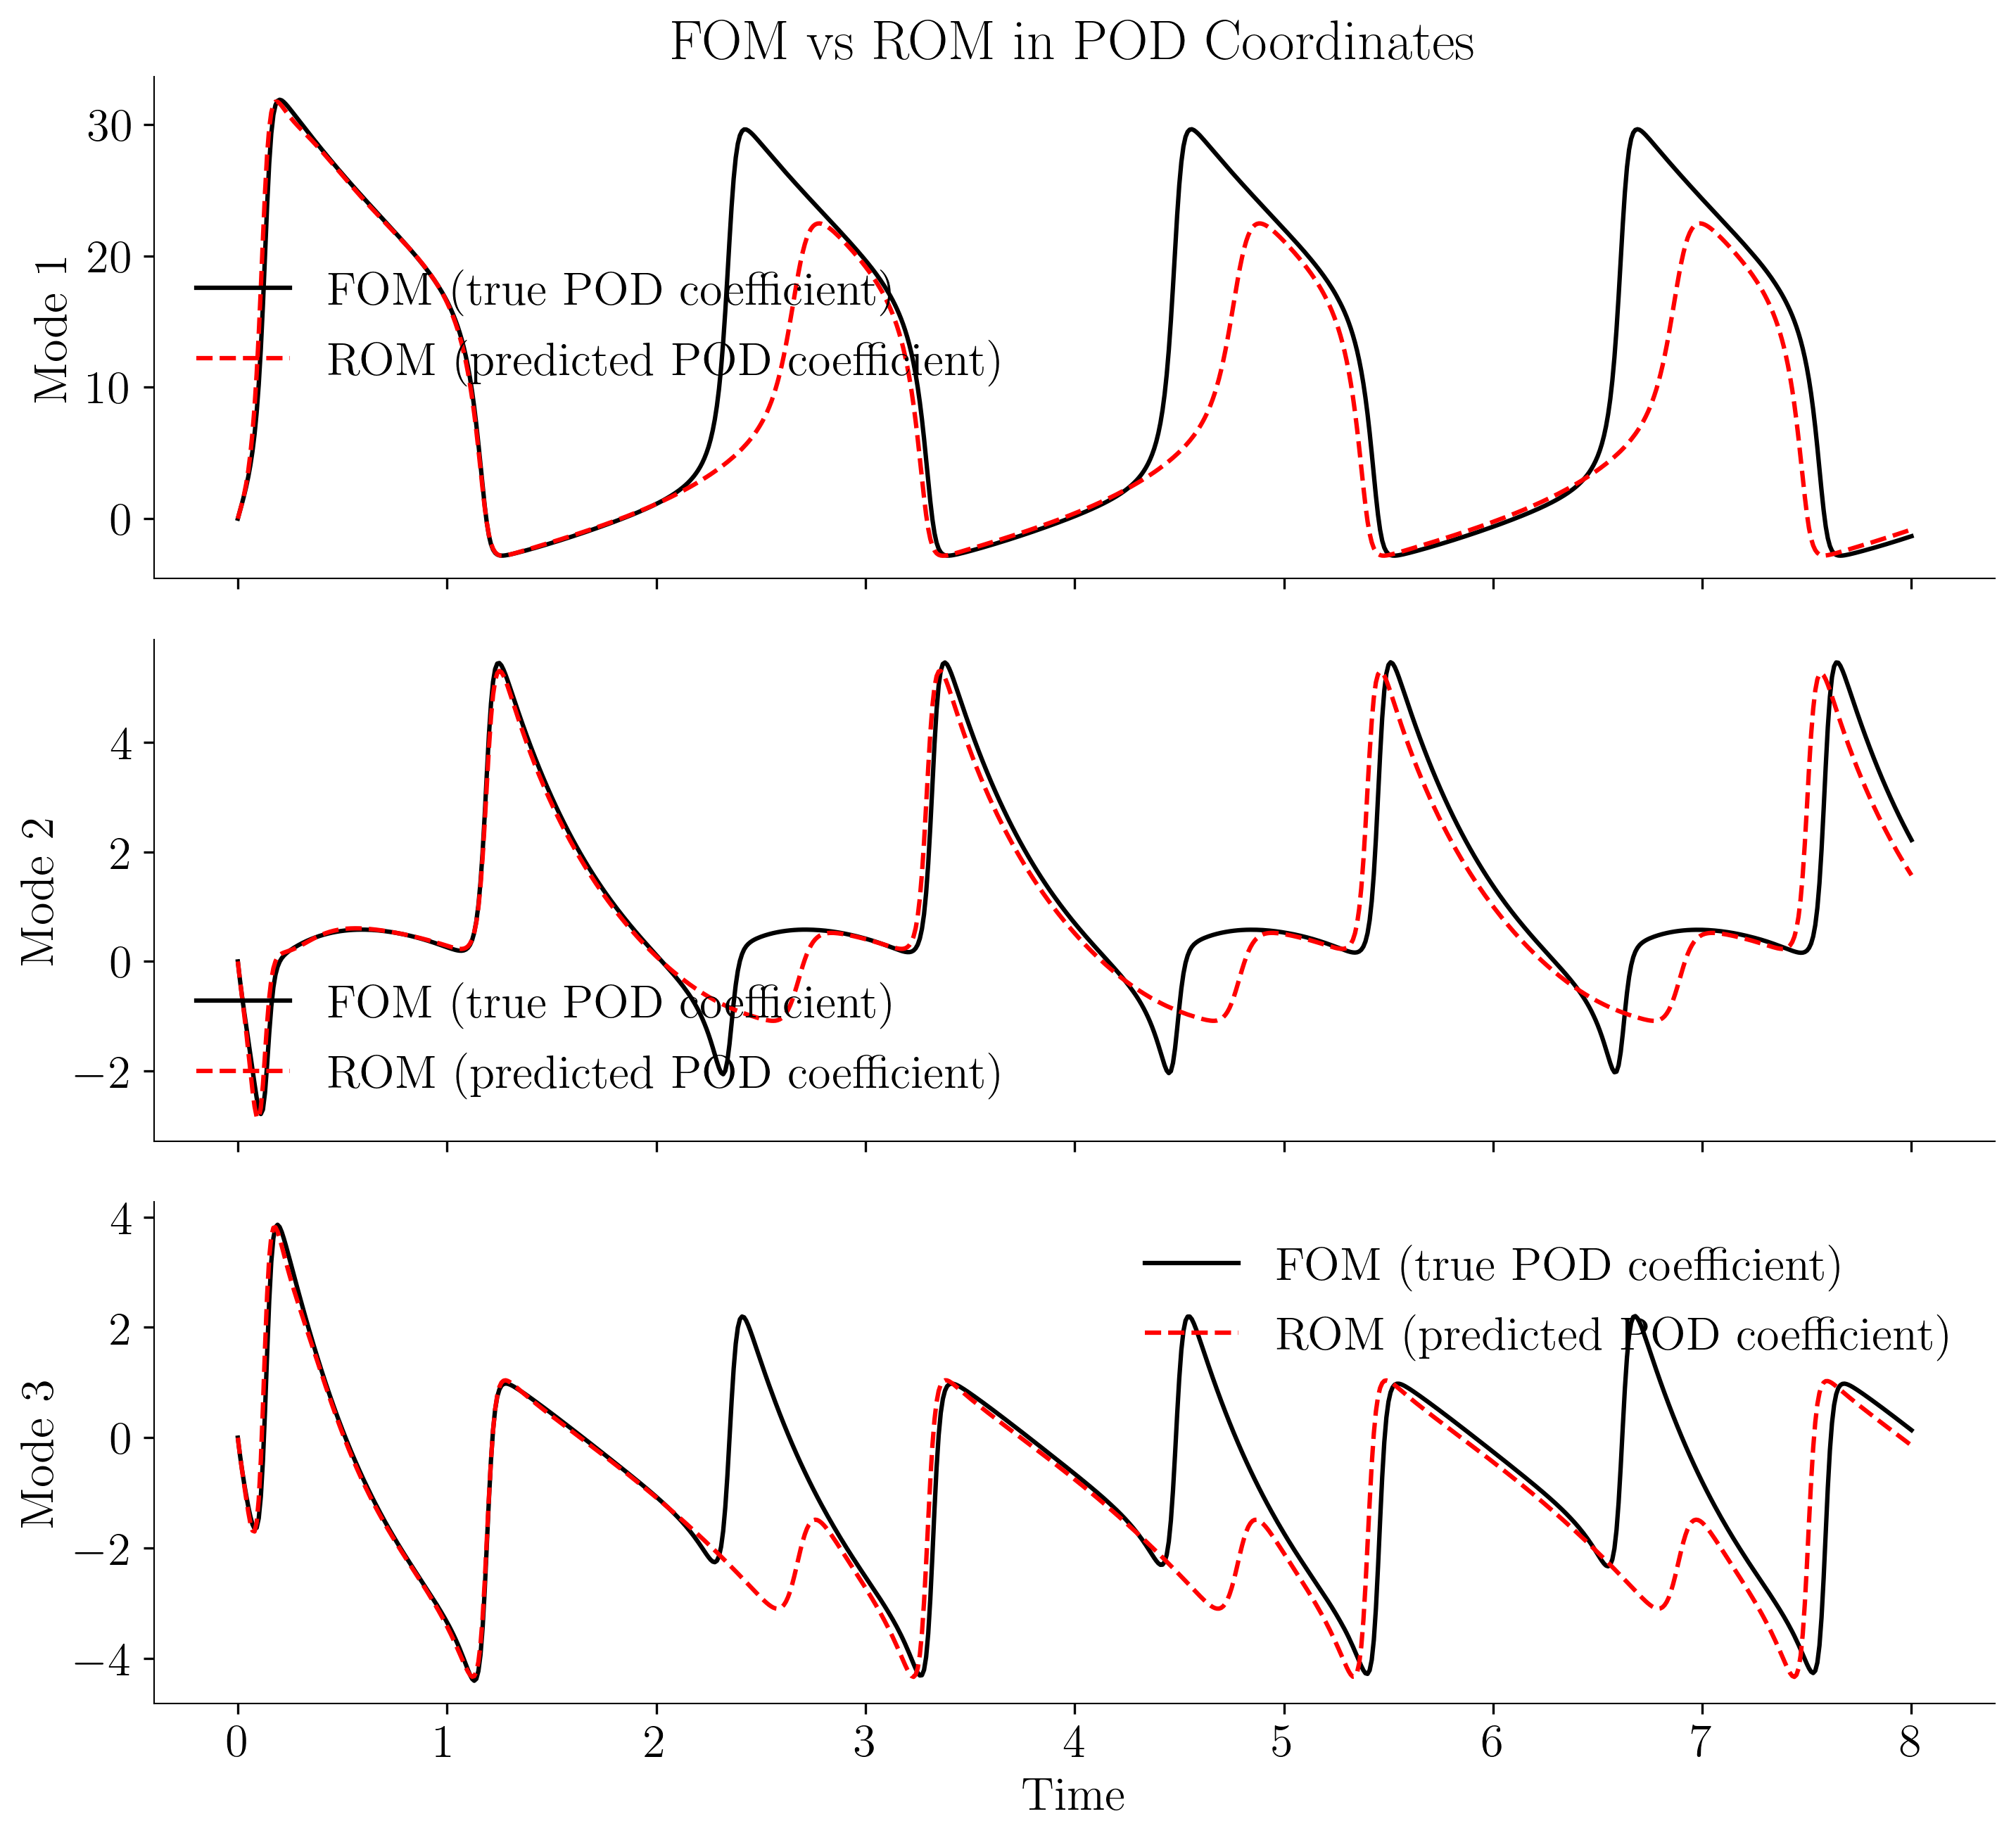

In [28]:
# Step 5: Plot FOM vs ROM in POD coordinates
# -------------------------------------------------------------------------
# Compute the reduced coordinates of the ROM prediction
reduced_Q_rom = basis.compress(Q_rom)

# full_states_compressed already contains the POD coefficients of the true FOM,
# with shape (numPODmodes, len(time_domain)).
# reduced_Q_rom now has the ROM’s predicted POD coefficients, same shape.

# Create a figure with one subplot per retained POD mode
fig, axes = plt.subplots(nrows=numPODmodes, ncols=1, figsize=(10, 3*numPODmodes), sharex=True)

for i in range(numPODmodes):
    ax = axes[i] if numPODmodes > 1 else axes
    # Plot the true POD coefficient (FOM) in solid black
    ax.plot(time_domain, full_states_compressed[i, :], 'k-', label='FOM (true POD coefficient)')
    # Plot the ROM-predicted POD coefficient in dashed red
    ax.plot(time_domain, reduced_Q_rom[i, :], 'r--', label='ROM (predicted POD coefficient)')
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.set_title('FOM vs ROM in POD Coordinates')
    if i == numPODmodes - 1:
        ax.set_xlabel('Time')
    ax.legend(loc='best')

plt.tight_layout()
plt.show()
